In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,f1_score,recall_score,confusion_matrix


In [95]:
main_df = pd.read_csv("/Users/utkuseyithanoglu/Desktop/nyc car crash analysis/data/raw/clean_crash_data.csv")

In [96]:
main_df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,Unspecified,4675373,2,0,1,1,Other
1,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,Unspecified,4456314,5,1,9,0,Car
2,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,Unspecified,4486609,1,0,8,0,Other
3,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
4,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,Unspecified,4486660,1,0,8,1,Car


In [97]:
main_df.isna().sum()

CRASH DATE                       0
CRASH TIME                       0
BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF PEDESTRIANS KILLED     0
NUMBER OF CYCLIST INJURED        0
NUMBER OF CYCLIST KILLED         0
NUMBER OF MOTORIST INJURED       0
NUMBER OF MOTORIST KILLED        0
CONTRIBUTING FACTOR VEHICLE 1    0
COLLISION_ID                     0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [98]:
top10 = main_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts().nlargest(10).index
top10=top10.drop("Unspecified")
def factor(x):
    if x in top10:
        return 1
    elif x=="Unspecified":
        return 0
    else:
        return 0
    



In [99]:
main_df['CONTRIBUTING FACTOR VEHICLE 1'] = main_df['CONTRIBUTING FACTOR VEHICLE 1'].apply(factor)

In [100]:
main_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts()

CONTRIBUTING FACTOR VEHICLE 1
0    1038177
1     998220
Name: count, dtype: int64

In [101]:
main_df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,0,4675373,2,0,1,1,Other
1,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,0,4456314,5,1,9,0,Car
2,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,0,4486609,1,0,8,0,Other
3,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,1,4486555,1,0,17,0,Car
4,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,0,4486660,1,0,8,1,Car


In [102]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2036397 entries, 0 to 2036396
Data columns (total 21 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   BOROUGH                        object 
 3   ZIP CODE                       int64  
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   NUMBER OF PERSONS INJURED      float64
 7   NUMBER OF PERSONS KILLED       float64
 8   NUMBER OF PEDESTRIANS INJURED  int64  
 9   NUMBER OF PEDESTRIANS KILLED   int64  
 10  NUMBER OF CYCLIST INJURED      int64  
 11  NUMBER OF CYCLIST KILLED       int64  
 12  NUMBER OF MOTORIST INJURED     int64  
 13  NUMBER OF MOTORIST KILLED      int64  
 14  CONTRIBUTING FACTOR VEHICLE 1  int64  
 15  COLLISION_ID                   int64  
 16  day_of_week                    int64  
 17  is_weekend                     int64  
 18  ho

In [103]:
main_df["CRASH TIME"] = pd.to_datetime(main_df["CRASH TIME"], format="%H:%M")

In [104]:
main_df['hour'] = main_df['CRASH TIME'].dt.hour

In [105]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2036397 entries, 0 to 2036396
Data columns (total 21 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   CRASH DATE                     object        
 1   CRASH TIME                     datetime64[ns]
 2   BOROUGH                        object        
 3   ZIP CODE                       int64         
 4   LATITUDE                       float64       
 5   LONGITUDE                      float64       
 6   NUMBER OF PERSONS INJURED      float64       
 7   NUMBER OF PERSONS KILLED       float64       
 8   NUMBER OF PEDESTRIANS INJURED  int64         
 9   NUMBER OF PEDESTRIANS KILLED   int64         
 10  NUMBER OF CYCLIST INJURED      int64         
 11  NUMBER OF CYCLIST KILLED       int64         
 12  NUMBER OF MOTORIST INJURED     int64         
 13  NUMBER OF MOTORIST KILLED      int64         
 14  CONTRIBUTING FACTOR VEHICLE 1  int64         
 15  COLLISION_ID   

In [106]:
main_df = main_df.drop(columns=['CRASH TIME'])

In [107]:
main_df['vehicle_category'].value_counts()

vehicle_category
Car      1084699
SUV       631666
Other     199984
Truck     120048
Name: count, dtype: int64

In [108]:
main_df['BOROUGH']=main_df['BOROUGH'].map({"BRONX": 0,"BROOKLYN": 1,"MANHATTAN": 2,"QUEENS": 3,
    "STATEN ISLAND": 4,
    "UNKNOWN": 5
})

In [109]:
main_df['BOROUGH']

0          1
1          1
2          1
3          5
4          0
          ..
2036392    0
2036393    5
2036394    2
2036395    5
2036396    5
Name: BOROUGH, Length: 2036397, dtype: int64

In [110]:
main_df['vehicle_category'] = main_df['vehicle_category'].map({"Car":0,"SUV":1,"Other":2,"Truck":3})

In [111]:
main_df.isna().sum()

CRASH DATE                       0
BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF PEDESTRIANS KILLED     0
NUMBER OF CYCLIST INJURED        0
NUMBER OF CYCLIST KILLED         0
NUMBER OF MOTORIST INJURED       0
NUMBER OF MOTORIST KILLED        0
CONTRIBUTING FACTOR VEHICLE 1    0
COLLISION_ID                     0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [112]:
main_df.head()

,CRASH DATE,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1,11230,40.621790,-73.970024,1.0,0.0,0,0,0,0,1,0,0,4675373,2,0,1,1,2
1,2021-09-11,1,11208,40.667202,-73.866500,0.0,0.0,0,0,0,0,0,0,0,4456314,5,1,9,0,0
2,2021-12-14,1,11233,40.683304,-73.917274,0.0,0.0,0,0,0,0,0,0,0,4486609,1,0,8,0,2
3,2021-12-14,5,0,40.709183,-73.956825,0.0,0.0,0,0,0,0,0,0,1,4486555,1,0,17,0,0
4,2021-12-14,0,10475,40.868160,-73.831480,2.0,0.0,0,0,0,0,2,0,0,4486660,1,0,8,1,0


In [113]:
main_df = main_df.drop(columns=['CRASH DATE','COLLISION_ID'])

In [114]:
main_df

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,1,11230,40.621790,-73.970024,1.0,0.0,0,0,0,0,1,0,0,2,0,1,1,2
1,1,11208,40.667202,-73.866500,0.0,0.0,0,0,0,0,0,0,0,5,1,9,0,0
2,1,11233,40.683304,-73.917274,0.0,0.0,0,0,0,0,0,0,0,1,0,8,0,2
3,5,0,40.709183,-73.956825,0.0,0.0,0,0,0,0,0,0,1,1,0,17,0,0
4,0,10475,40.868160,-73.831480,2.0,0.0,0,0,0,0,2,0,0,1,0,8,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2036392,0,10453,40.854816,-73.911500,3.0,0.0,0,0,0,0,3,0,1,1,0,12,1,2
2036393,5,0,40.665520,-73.744670,0.0,0.0,0,0,0,0,0,0,1,1,0,19,0,1
2036394,2,10002,40.721798,-73.988240,0.0,0.0,0,0,0,0,0,0,0,5,1,23,0,1
2036395,5,0,40.834114,-73.863270,2.0,0.0,0,0,0,0,2,0,1,1,0,22,1,1


<Axes: xlabel='BOROUGH', ylabel='injury_flag'>

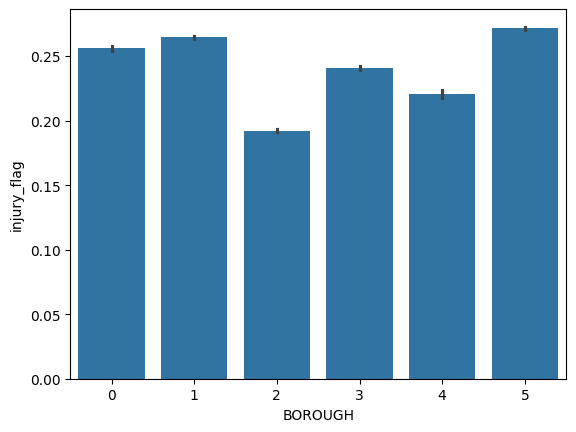

In [115]:
sns.barplot(data=main_df,x='BOROUGH',y='injury_flag')

<Axes: xlabel='injury_flag', ylabel='vehicle_category'>

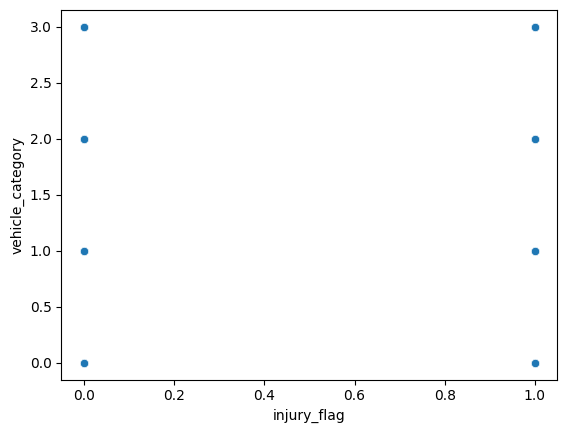

In [116]:
sns.scatterplot(data=main_df,x='injury_flag',y='vehicle_category')

In [117]:
main_df.isna().sum()

BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF PEDESTRIANS KILLED     0
NUMBER OF CYCLIST INJURED        0
NUMBER OF CYCLIST KILLED         0
NUMBER OF MOTORIST INJURED       0
NUMBER OF MOTORIST KILLED        0
CONTRIBUTING FACTOR VEHICLE 1    0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [118]:
main_df=main_df.drop(columns=[
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF MOTORIST KILLED"])

In [119]:
train_df,test_df = train_test_split(main_df,random_state=46)

In [120]:
train_df.isna().sum()

BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
CONTRIBUTING FACTOR VEHICLE 1    0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [121]:
test_df.isna().sum()

BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
CONTRIBUTING FACTOR VEHICLE 1    0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [122]:
x_train = train_df.drop(columns=['injury_flag'])
x_test = test_df.drop(columns=['injury_flag'])


In [123]:
y_train = train_df['injury_flag']
y_test = test_df['injury_flag']


In [124]:
y_train

863705     0
413773     0
1528850    0
6803       0
1990456    0
          ..
84410      1
580980     0
292392     0
1006405    0
605373     1
Name: injury_flag, Length: 1527297, dtype: int64

In [125]:
x_train

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,CONTRIBUTING FACTOR VEHICLE 1,day_of_week,is_weekend,hour,vehicle_category
863705,5,0,40.732136,-73.919014,1,6,1,13,1
413773,0,10464,40.840702,-73.784070,0,3,0,10,2
1528850,3,11362,40.760561,-73.728815,1,1,0,10,1
6803,1,11213,40.668120,-73.928420,1,3,0,16,0
1990456,3,11412,40.691936,-73.753160,0,1,0,18,1
...,...,...,...,...,...,...,...,...,...
84410,1,11220,40.643986,-74.011490,0,3,0,11,0
580980,2,10016,40.748302,-73.978350,1,0,0,19,1
292392,2,10035,40.805737,-73.940650,0,6,1,21,0
1006405,5,0,40.680225,-74.004810,1,2,0,9,1


In [126]:
from sklearn.ensemble import RandomForestClassifier

In [127]:
rf_model = RandomForestClassifier(class_weight="balanced")
rf_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [128]:


def model_evaluator(X, y, model):
    preds = model.predict(X)

    print("accuracy:", accuracy_score(y, preds))
    print("f1:", f1_score(y, preds))
    print("recall:", recall_score(y, preds))
    print(classification_report(y, preds))
    print(confusion_matrix(y,preds))

In [129]:
model_evaluator(x_train, y_train, rf_model)

accuracy: 0.9889746395101935
f1: 0.9779916012845095
recall: 0.9920743089879298
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1150169
           1       0.96      0.99      0.98    377128

    accuracy                           0.99   1527297
   macro avg       0.98      0.99      0.99   1527297
weighted avg       0.99      0.99      0.99   1527297

[[1136319   13850]
 [   2989  374139]]


In [130]:
model_evaluator(x_test, y_test, rf_model)

accuracy: 0.7229385189550187
f1: 0.18166206400408438
recall: 0.12481066343532263
              precision    recall  f1-score   support

           0       0.76      0.92      0.83    383662
           1       0.33      0.12      0.18    125438

    accuracy                           0.72    509100
   macro avg       0.55      0.52      0.51    509100
weighted avg       0.66      0.72      0.67    509100

[[352392  31270]
 [109782  15656]]


In [131]:
y_prob = rf_model.predict_proba(x_test)[:,1]

In [132]:
y_prob

array([0.04      , 0.11      , 0.17      , ..., 0.18      , 0.18753075,
       0.36      ], shape=(509100,))

In [133]:
y_pred = (y_prob >= 0.3).astype(int)

In [136]:


print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

accuracy: 0.6217108623060302
f1: 0.33574885058858833
recall: 0.38801639056745163
              precision    recall  f1-score   support

           0       0.78      0.70      0.74    383662
           1       0.30      0.39      0.34    125438

    accuracy                           0.62    509100
   macro avg       0.54      0.54      0.54    509100
weighted avg       0.66      0.62      0.64    509100

[[267841 115821]
 [ 76766  48672]]


In [137]:
y_pred = (y_prob >= 0.35).astype(int)

In [138]:


print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

accuracy: 0.6583598507169515
f1: 0.3036628672776116
recall: 0.3023326264768252
              precision    recall  f1-score   support

           0       0.77      0.77      0.77    383662
           1       0.31      0.30      0.30    125438

    accuracy                           0.66    509100
   macro avg       0.54      0.54      0.54    509100
weighted avg       0.66      0.66      0.66    509100

[[297247  86415]
 [ 87514  37924]]


In [139]:
y_pred = (y_prob >= 0.28).astype(int)

In [140]:


print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

accuracy: 0.604433313690827
f1: 0.34724630728688904
recall: 0.42702370892393055
              precision    recall  f1-score   support

           0       0.78      0.66      0.72    383662
           1       0.29      0.43      0.35    125438

    accuracy                           0.60    509100
   macro avg       0.54      0.54      0.53    509100
weighted avg       0.66      0.60      0.63    509100

[[254152 129510]
 [ 71873  53565]]


In [141]:
y_pred = (y_prob >= 0.24).astype(int)

In [142]:


print("accuracy:", accuracy_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

accuracy: 0.5635042231388725
f1: 0.36632409804838545
recall: 0.5120617356781837
              precision    recall  f1-score   support

           0       0.78      0.58      0.67    383662
           1       0.29      0.51      0.37    125438

    accuracy                           0.56    509100
   macro avg       0.53      0.55      0.52    509100
weighted avg       0.66      0.56      0.59    509100

[[222648 161014]
 [ 61206  64232]]


In [143]:
np.round(pd.DataFrame(rf_model.feature_importances_,rf_model.feature_names_in_)*100,2).sort_values(by=0,ascending=False)

,0
LONGITUDE,34.99
LATITUDE,34.25
hour,12.15
day_of_week,8.27
ZIP CODE,4.48
vehicle_category,3.35
CONTRIBUTING FACTOR VEHICLE 1,1.42
is_weekend,0.74
BOROUGH,0.36
